# Import Libraries

In [7]:
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from skimage.transform import resize

from sklearn.utils import shuffle 
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.optimizers import Adamax
from sklearn.metrics import classification_report, confusion_matrix


In [9]:
import sys

sys.path.append(os.path.join(os.getcwd(), 'notebook'))
from logger import logger

logger.info("Starting the Brain Tumor Classification Pipeline.")

[ 2025-08-26 11:19:37,907 ] 9 deeplearning_logger - INFO - Starting the Brain Tumor Classification Pipeline.


# Defining Labels

In [10]:
labels = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Loading Dataset

In [5]:
logger.info("Defining configuration parameters.")

[ 2025-08-26 10:21:18,186 ] 1 deeplearning_logger - INFO - Defining configuration parameters.


In [11]:
train_dir = r"e:\HealthCareProject\DeepLearning_module\notebook\img_data\brain_tumor_mri_dataset\Training"
test_dir = r"e:\HealthCareProject\DeepLearning_module\notebook\img_data\brain_tumor_mri_dataset\Testing"


X_train = [] #Training Dataset
Y_train = [] #Training Labels

image_size=224

for label in labels:
    path = os.path.join(train_dir, label)
    class_num = labels.index(label)
    for img in os.listdir(path):
        img_array = plt.imread(os.path.join(path, img))
        img_resized = resize(img_array, (image_size, image_size, 3))
        X_train.append(img_resized)
        Y_train.append(class_num)

for label in labels:
    path = os.path.join(test_dir, label)
    class_num = labels.index(label)
    for img in os.listdir(path):
        img_array = plt.imread(os.path.join(path, img))
        img_resized = resize(img_array, (image_size, image_size, 3))
        X_train.append(img_resized)
        Y_train.append(class_num)

X_train = np.array(X_train)
Y_train = np.array(Y_train)

MemoryError: Unable to allocate 7.88 GiB for an array with shape (7023, 224, 224, 3) and data type float64

In [ ]:
print(X_train.valuecounts())

In [ ]:
logger.info("Performing Exploratory Data Analysis (EDA) on class distribution.")
# Calculate class counts
class_counts = Counter(Y_train_raw)
class_names = [labels[i] for i in class_counts.keys()]
counts = [class_counts[i] for i in class_counts.keys()]

# Plot the class distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=class_names, y=counts, palette='viridis')
plt.title('Brain MRI Dataset Class Distribution', fontsize=16)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.show()
logger.info(f"Class distribution plot generated. Counts: {class_counts}")

The 4 output classes almost are almost balanced

In [ ]:
logger.info(f"Training data directory: {train_dir}")
logger.info(f"Testing data directory: {test_dir}")

In [4]:
#Number of sample = 7023
X_train.shape

(7023, 224, 224, 3)

In [ ]:
logger.info("Loading images from directories.")

In [5]:
# Shuffling data
X_train, Y_train = shuffle(X_train, Y_train, random_state=42)

In [6]:
#After shuffling sample size remains same
X_train.shape

(7023, 224, 224, 3)

# Ploting Some Images

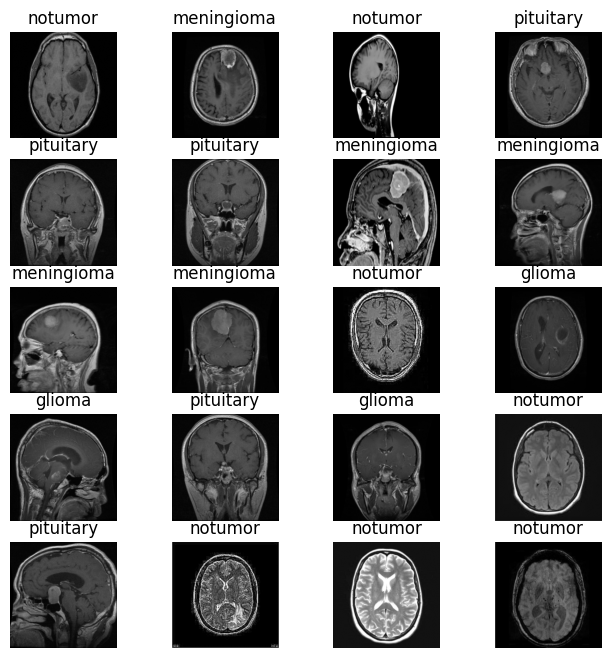

In [7]:
#plotting the images
plt.figure(figsize=(8,8))
for i in range(20):
    plt.subplot(5,4,i+1)
    plt.imshow(X_train[i])
    plt.title(labels[Y_train[i]])
    plt.axis("off")
plt.show()

# Splitting data into : Train, Test, Valid as 70, 20, 10 ratio

In [8]:
# Split the data into training and testing and validation
X_train, X_test, Y_train, Y_test = train_test_split(X_train, Y_train, test_size=0.2, random_state=42)
X_train, X_valid, Y_train, Y_valid = train_test_split(X_train, Y_train, test_size=0.1, random_state=42)

In [ ]:
logger.info(f"Training set size: {len(X_train)}")
logger.info(f"Validation set size: {len(X_valid)}")
logger.info(f"Testing set size: {len(X_test)}")

# converting string to categorical

In [9]:
# Data augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

datagen.fit(X_train)

# convert string to categorical
y_train_new = to_categorical(Y_train, num_classes=4)
y_valid_new = to_categorical(Y_valid, num_classes=4)
y_test_new = to_categorical(Y_test, num_classes=4)


# Load pre-trained Model (MobileNetV2)

In [10]:
from keras.applications import ResNet50

# Load ResNet50 model with pre-trained weights
base_model = ResNet50(input_shape=(image_size, image_size, 3), include_top=False, weights='imagenet')

# Unfreeze some layers in the base model
for layer in base_model.layers[-30:]:
    layer.trainable = True

# Build the model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

# Compile the model
model.compile(Adamax(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks for early stopping and model checkpoint
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('Bmodel.h5', monitor='val_loss', save_best_only=True)

# Model summary
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 128)               262272    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 4)                 516       
                                                        

# Training the model

In [11]:
# Fit the model
history = model.fit(datagen.flow(X_train, y_train_new, batch_size=32),
                    epochs=12,  # Increase the number of epochs as needed
                    validation_data=(X_valid, y_valid_new),
                    callbacks=[early_stopping, checkpoint])

Epoch 1/12


I0000 00:00:1756146251.304120    1461 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


158/158 [==============================] - ETA: 0s - loss: 0.7851 - accuracy: 0.6980

/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


158/158 [==============================] - 104s 445ms/step - loss: 0.7851 - accuracy: 0.6980 - val_loss: 1.5158 - val_accuracy: 0.2580
Epoch 2/12
158/158 [==============================] - 69s 437ms/step - loss: 0.3550 - accuracy: 0.8754 - val_loss: 1.4266 - val_accuracy: 0.3399
Epoch 3/12
158/158 [==============================] - 70s 443ms/step - loss: 0.2443 - accuracy: 0.9155 - val_loss: 1.4010 - val_accuracy: 0.5160
Epoch 4/12
158/158 [==============================] - 69s 436ms/step - loss: 0.1900 - accuracy: 0.9361 - val_loss: 1.4480 - val_accuracy: 0.5409
Epoch 5/12
158/158 [==============================] - 71s 445ms/step - loss: 0.1572 - accuracy: 0.9482 - val_loss: 1.2584 - val_accuracy: 0.5801
Epoch 6/12
158/158 [==============================] - 71s 445ms/step - loss: 0.1202 - accuracy: 0.9616 - val_loss: 0.5946 - val_accuracy: 0.7705
Epoch 7/12
158/158 [==============================] - 71s 445ms/step - loss: 0.0972 - accuracy: 0.9660 - val_loss: 0.1858 - val_accuracy: 0.

# Save the model

In [12]:
# Load the best model
model = load_model('Bmodel.h5')

# Accurcy and Loss visualization

44/44 [==============================] - 9s 174ms/step - loss: 0.0576 - accuracy: 0.9801


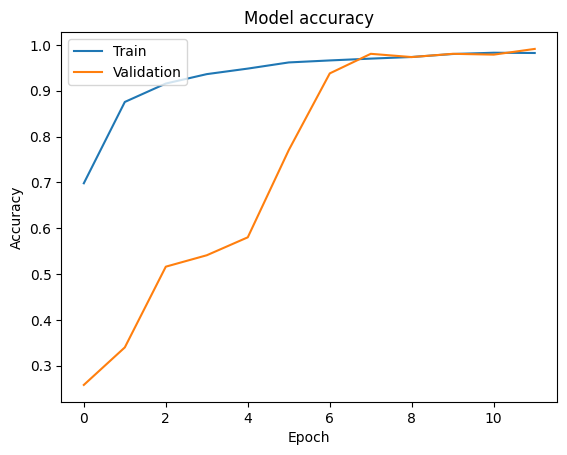

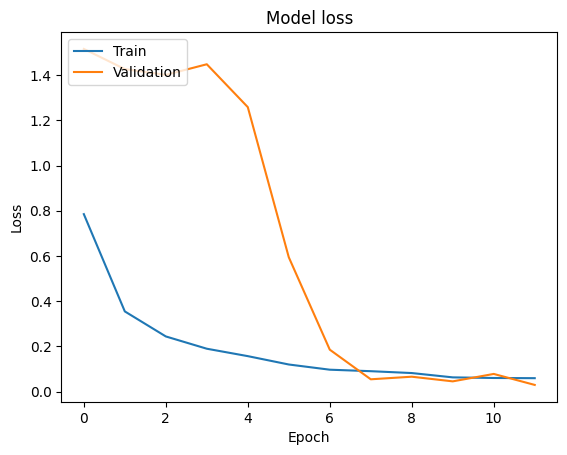

In [13]:
#Evaluate the model
model.evaluate(X_test, y_test_new)

# Plot the accuracy and loss
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Confusion matrix

44/44 [==============================] - 6s 120ms/step


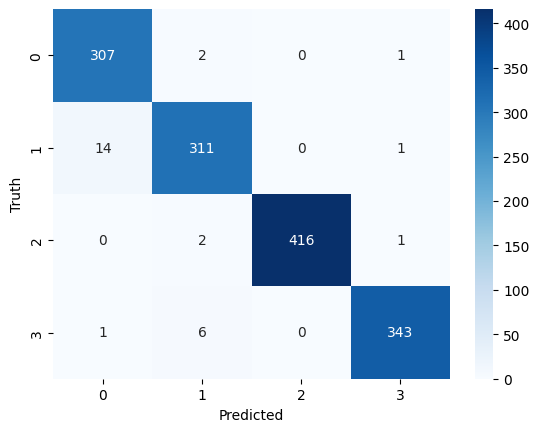

In [14]:
# Predict the model
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

# Confusion matrix
cm = confusion_matrix(Y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

# Classification report

In [15]:
# Classification report
print(classification_report(Y_test, y_pred, target_names=labels))

              precision    recall  f1-score   support

      glioma       0.95      0.99      0.97       310
  meningioma       0.97      0.95      0.96       326
     notumor       1.00      0.99      1.00       419
   pituitary       0.99      0.98      0.99       350

    accuracy                           0.98      1405
   macro avg       0.98      0.98      0.98      1405
weighted avg       0.98      0.98      0.98      1405



# Visualizing Model Predictions

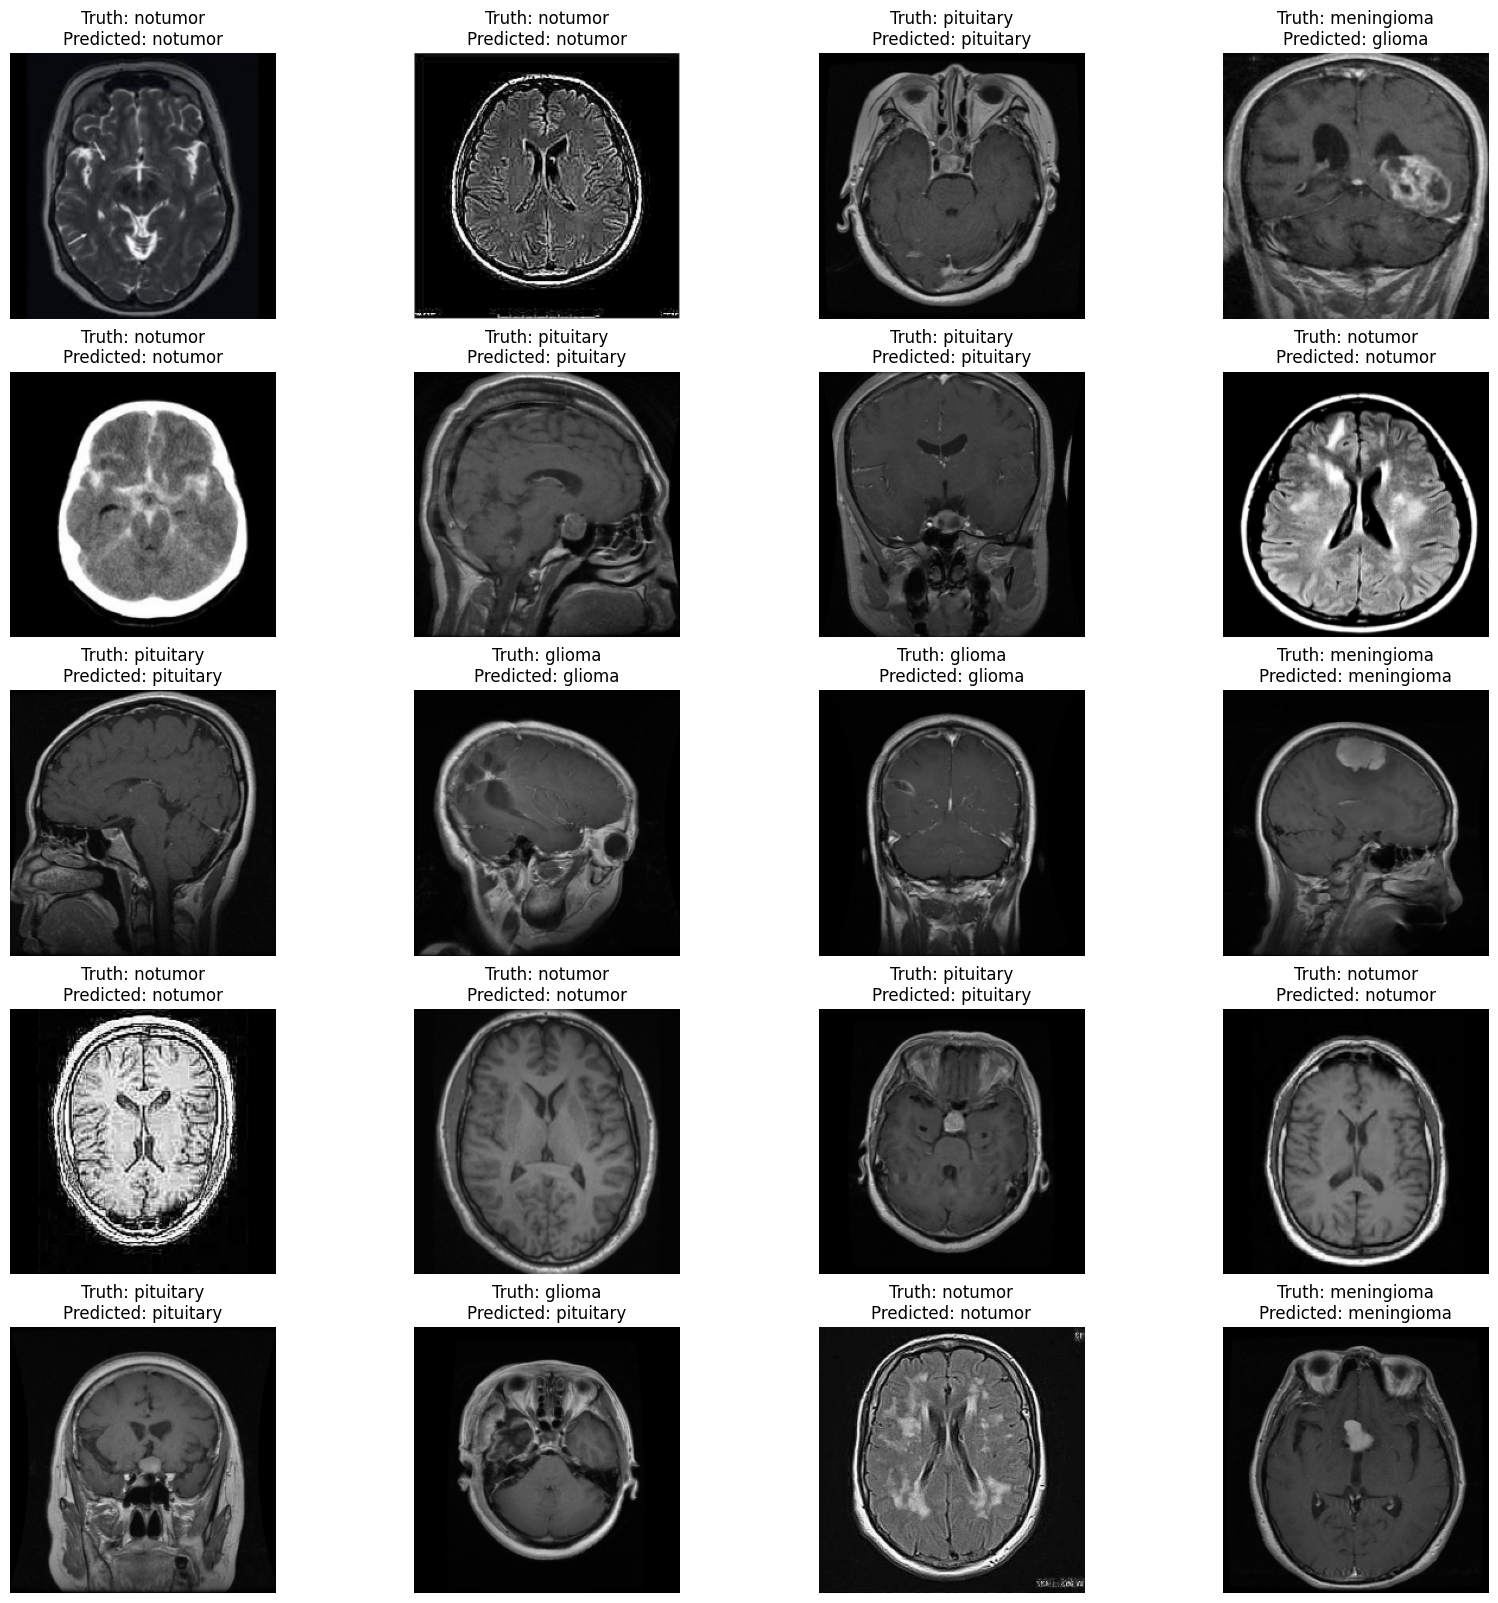

In [16]:
# Visualizing Model Predictions
plt.figure(figsize=(20,20))
for i in range(20):
    plt.subplot(5,4,i+1)
    plt.imshow(X_test[i])
    plt.title(f"Truth: {labels[Y_test[i]]}\nPredicted: {labels[y_pred[i]]}")
    plt.axis('off')
plt.show()

In [17]:
#testing accuracy
from sklearn.metrics import accuracy_score
print(accuracy_score(Y_test, y_pred))

0.9800711743772242


Resnet model is performing well compared to VGG and Custom model